In [1]:
from pathlib import Path
import sys
import os

current_dir = os.getcwd()
_ROOT = Path(current_dir).parents[0]
print(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
from utils.rl_core import compute_reinforce_plus_plus_distance_kernel_advantage, collate_trajectories,compute_reinforce_plus_plus_distance_kernel_var_norm_advantage

/Projects/spatial_training


/root/conda/envs/vlm_node_1016/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-18 23:55:05,145	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
import pickle
dbg_dir = "/Projects/spatial_training/dump/rl_eval/rpp_t_clipcov_ckpt_247/dbg/"
import glob
traj_pickle_files = glob.glob(dbg_dir+"rollout*")
trajs = []
for name in traj_pickle_files:
    try:
        with open(name,'rb') as f:
            traj = pickle.load(f)
            traj = [t[0] for t in traj]
            trajs+=traj
    except:
        pass

In [38]:
traj_batch = collate_trajectories(trajs[:4])
print(traj_batch.shape)

torch.Size([4, 400])


In [44]:
from config_schema import RLAlgoConfig
conf = RLAlgoConfig(gamma=0.95,distance_kernel_sigma=0.5)
adv_tuple = compute_reinforce_plus_plus_distance_kernel_var_norm_advantage(traj_batch['rewards'],traj_batch['response_mask'],distances=traj_batch['distance_to_goal'],config = conf)
# adv_tuple = compute_reinforce_plus_plus_distance_kernel_advantage(traj_batch['rewards'],traj_batch['response_mask'],distances=traj_batch['distance_to_goal'],config = conf)
adv,rtn = adv_tuple[0],adv_tuple[1]
baseline = adv_tuple[2]
try:
    std = adv_tuple[3]
except:
    pass
traj_batch['returns'] = rtn
traj_batch['advantage'] = adv

In [72]:
print(traj_batch['advantage'])

tensor([[ 0.1675,  0.2220,  0.2794,  ..., -0.0000, -0.0000, -0.0000],
        [-0.0597, -0.0408, -0.0209,  ..., -0.0000, -0.0000, -0.0000],
        [ 0.5264,  0.6090,  0.6961,  ..., -0.0000, -0.0000, -0.0000],
        ...,
        [-1.1245, -1.0690, -1.0797,  ..., -0.0000, -0.0000, -0.0000],
        [-1.3787, -1.4056, -1.4339,  ..., -0.0000, -0.0000, -0.0000],
        [ 1.2554,  1.1633,  1.1214,  ..., -0.0000, -0.0000, -0.0000]])


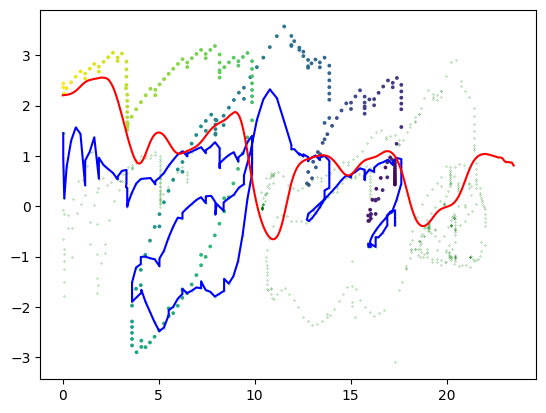

In [46]:
import matplotlib.pyplot as plt
import numpy as np
y = rtn[traj_batch['response_mask']>0]
x = traj_batch['distance_to_goal'][traj_batch['response_mask']>0]
z = adv[traj_batch['response_mask']>0]
i = 1
traj_sample = traj_batch[i][traj_batch['response_mask'][i]>0]
traj_l = len(traj_sample)
plt.scatter(traj_sample['distance_to_goal'],traj_sample['returns'],c=np.arange(traj_l),s=3)
plt.plot(traj_sample['distance_to_goal'],traj_sample['advantage'],c='b')
# plt.scatter(x,y,s=0.04)
plt.scatter(x,z,s=0.04,c='g')
plt.plot(np.arange(len(baseline))*0.1,baseline,c='r')

In [35]:
traj_sample['advantage'][-1]

tensor(0.2795)

In [75]:
baseline[0]

tensor(2.1049)

In [76]:
a,_ = 1,

ValueError: not enough values to unpack (expected 2, got 1)

In [ ]:
baseline.shape

torch.Size([292])